In [1]:
import numpy as np
from scipy.integrate import solve_ivp

step = 100


x = np.linspace(0, 2*np.pi, step)
x_step = 2*np.pi/step


def d(u, r = 1):
    if r == 1:
        u = np.concatenate([u,np.array(u[:1])])
    elif r ==2:
        u = np.concatenate([np.array(u[-1:]), u])
    else:
        raise RuntimeError()
    return (u[1:] - u[:-1])/x_step

def K(x):
    return 1+0.5*np.sin(x)

def K_p(x):
    return 0.5*np.cos(x)

def dxKdxu(t, u):
    return d(K(x)*d(u), r = 2)


y0 = np.cos(x) + np.cos(3*x)/2 + np.cos(5*x)/4

r = [0, 0.1]
e = np.array(range(11))/100

y = solve_ivp(dxKdxu, r, y0, t_eval = e)

In [2]:
from utils.pde import PDE

pde_dxKdxu_txt = 'h_1*D[1, 0]+h_0*D[2, 0, 0]'

pde_dxKdxu = PDE(pde_dxKdxu_txt, equal_time_derivative = True)

In [3]:
from utils.triangulation import Triangulation
from utils.finite_element import LagrangeBasis, FiniteElement
from utils.tensor_network import TensorUnit, TensorNetwork
from utils.solver import DMRG

triangulation = Triangulation(np.linspace(0, 2*np.pi, 11))
basis = LagrangeBasis(1, 5)

In [4]:
fe = FiniteElement(triangulation, basis)
fe.set_con_bc_operators(1)
fe.set_env_bc_operators({0: {1: ([np.array([[0]]), np.array([[[1]]])], 
                                  np.array([[0]]))},
                         9: {0: ([np.array([[0]]), np.array([[[1]]])], 
                                  np.array([[0]]))}})
# fe.set_env_bc_operators({})
fe.calculate_higher_domain_derivatives(2)

bond_order = 1
delta = 0.01

K_rep = fe.fun2rep(K)
K_p_rep = fe.fun2rep(K_p)
h_tensor_units = []
for rep in [K_rep, K_p_rep]:
    rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
    h_tensor_units.append(TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0))


tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)
tn.set_u_shape(tuple())
tn.set_h_tensor_units(h_tensor_units)

y0 = lambda x: np.cos(x) + np.cos(3*x)/2 + np.cos(5*x)/4
rep = fe.fun2rep(y0)
rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

all_reps = [[states.tensor[..., 0, 0].copy()]]
for j, (reps, pde) in enumerate(zip(all_reps, [pde_dxKdxu])):
    for i in range(10):
        print(i)
        pde_operators, pde_power =  tn.get_operators_from_pde(pde.pde, delta, states.copy())
        tn.set_states(states, bond_order)
        tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
        tn.set_solver(DMRG())
        tn.set_operators(pde_operators, pde_power)
        states = tn.solve(rounds = 20, alpha = 1, env = True)
        reps.append(states.tensor[..., 0, 0].copy())
    states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

0
1
2
3
4
5
6
7
8
9


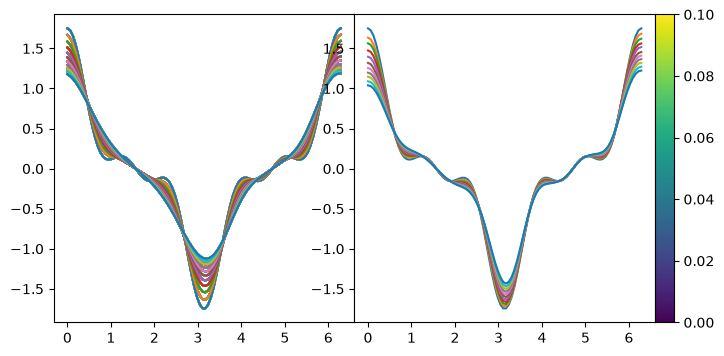

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

fig, axs = plt.subplots(1, 3, sharey = False, sharex = False, figsize = (8, 4), width_ratios = [0.32, 0.32, 0.02])
fig.subplots_adjust(wspace = 0)
for i, (reps, y) in enumerate(zip(all_reps, [y])):
    for j, rep in enumerate(reps):
        dy = fe.rep2fun(rep)(x) - y.y[..., j]
        axs[0].plot(x, y.y)
        axs[1].plot(x, fe.rep2fun(rep)(x))
    # if i != 0:
        # ax.tick_params(labelleft = False, left = False)
    # ax.set_ylim(-0.02, 0.02)
colormap = mpl.colormaps['viridis']
sm = plt.cm.ScalarMappable(cmap = colormap)
sm.set_clim(vmin = 0, vmax = 0.1)
fig.colorbar(sm, cax = axs[-1])
fig.savefig('diffuse_diff.png', dpi = 400)